# Task 3 - Feature Engineering (Part 2)

*This notebook is the second part of the Data Cleaning & Feature Engineering task.*

In this notebook, we will perform feature engineering to prepare the cleaned dataset for machine learning modeling.

---
## Objectives

1. **Ordinal Encoding**: Convert categorical variables with a clear rank into numerical values.
2. **Numerical Transformation**: Handle skewed distributions if necessary.
3. **Feature Scaling**: Ensure numerical features are on a similar scale.
4. **Saving the Engineered Dataset**: Save the fully prepared dataframe to a CSV file for the upcoming predictive modeling stage.

**Input Data:** We are using the dataset saved in the previous step: `outputs/datasets/cleaned/cleaned_house_prices_records.csv`.

In [1]:
import pandas as pd

# Load the cleaned dataset using the absolute path in the workspace
file_path = "/workspaces/heritage-housing-issues/outputs/datasets/cleaned/cleaned_house_prices_records.csv"
df = pd.read_csv(file_path)

# Verify successful loading by checking the dataframe dimensions
print(f"✅ Success! Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")
df.head(5)

✅ Success! Dataset loaded with 1460 rows and 22 columns.


,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtExposure,BsmtFinSF1,BsmtFinType1,BsmtUnfSF,GarageArea,GarageFinish,GarageYrBlt,...,LotArea,LotFrontage,MasVnrArea,OpenPorchSF,OverallCond,OverallQual,TotalBsmtSF,YearBuilt,YearRemodAdd,SalePrice
0,856,854.0,3.0,No,706,GLQ,150,548,RFn,2003.0,...,8450,65.0,196.0,61,5,7,856,2003,2003,208500
1,1262,0.0,3.0,Gd,978,ALQ,284,460,RFn,1976.0,...,9600,80.0,0.0,0,8,6,1262,1976,1976,181500
2,920,866.0,3.0,Mn,486,GLQ,434,608,RFn,2001.0,...,11250,68.0,162.0,42,5,7,920,2001,2002,223500
3,961,0.0,3.0,No,216,ALQ,540,642,Unf,1998.0,...,9550,60.0,0.0,35,5,7,756,1915,1970,140000
4,1145,0.0,4.0,Av,655,GLQ,490,836,RFn,2000.0,...,14260,84.0,350.0,84,5,8,1145,2000,2000,250000


---
## 1. Ordinal Encoding

In this section, we will map our categorical features that have a clear ordinal structure (e.g., quality ratings like "Poor", "Typical", "Good", "Excellent") into numerical values. This allows the machine learning model to understand the hierarchical relationship between these categories.

In [2]:
# 1. Define mapping dictionaries based on the project data dictionary
mapping_quality = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
mapping_exposure = {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
mapping_fin_type = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
mapping_garage = {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}

# 2. Apply the ordinal mapping to categorical variables
df['KitchenQual'] = df['KitchenQual'].map(mapping_quality)
df['BsmtExposure'] = df['BsmtExposure'].map(mapping_exposure)
df['BsmtFinType1'] = df['BsmtFinType1'].map(mapping_fin_type)
df['GarageFinish'] = df['GarageFinish'].map(mapping_garage)

# 3. Check if all categorical columns were successfully converted to numerical
remaining_objects = df.select_dtypes(include=['object']).columns.tolist()
print(f"Remaining object columns: {remaining_objects}")
df[['KitchenQual', 'BsmtExposure', 'BsmtFinType1', 'GarageFinish']].head()

Remaining object columns: []


,KitchenQual,BsmtExposure,BsmtFinType1,GarageFinish
0,4,1.0,6.0,2.0
1,3,4.0,5.0,2.0
2,4,2.0,6.0,2.0
3,4,1.0,5.0,1.0
4,4,3.0,6.0,2.0


---
## 2. Numerical Transformation

Here, we will analyze the distribution of our numerical variables. If we identify features with highly skewed distributions (like area or price), or absolute years that need to be converted to "age", we will apply mathematical transformations to make them more suitable for the predictive model.

### Converting Absolute Years to "Age"

Machine learning models generally extract more value from relative time intervals (ages) than from absolute calendar years. Since the Ames housing dataset records sales up to the year 2010, we will use 2010 as our constant reference point. 

We will create new features representing the age of the house, the time since its last remodel, and the age of the garage. To prevent redundancy and potential multicollinearity issues, the original year columns will be dropped after the calculations are complete.

In [3]:
# Set the reference year for calculations (Ames dataset was collected up to 2010)
reference_year = 2010

# 1. Calculate the age of the property, remodel, and garage
df['HouseAge'] = reference_year - df['YearBuilt']
df['RemodelAge'] = reference_year - df['YearRemodAdd']
df['GarageAge'] = reference_year - df['GarageYrBlt']

# 2. Drop the original year columns to avoid redundancy (multicollinearity)
columns_to_drop = ['YearBuilt', 'YearRemodAdd', 'GarageYrBlt']
df = df.drop(columns=columns_to_drop, axis=1)

# 3. Verify the creation of the new age features
print("Successfully created Age features and dropped original Year columns.")
print(df[['HouseAge', 'RemodelAge', 'GarageAge']].head())

Successfully created Age features and dropped original Year columns.
   HouseAge  RemodelAge  GarageAge
0         7           7        7.0
1        34          34       34.0
2         9           8        9.0
3        95          40       12.0
4        10          10       10.0


**The new Data Frame** resulted after adding new `HouseAge`, `RemodelAge` and `GarageAge` with it their years value below:

In [4]:
df.head(5)

,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtExposure,BsmtFinSF1,BsmtFinType1,BsmtUnfSF,GarageArea,GarageFinish,GrLivArea,...,LotFrontage,MasVnrArea,OpenPorchSF,OverallCond,OverallQual,TotalBsmtSF,SalePrice,HouseAge,RemodelAge,GarageAge
0,856,854.0,3.0,1.0,706,6.0,150,548,2.0,1710,...,65.0,196.0,61,5,7,856,208500,7,7,7.0
1,1262,0.0,3.0,4.0,978,5.0,284,460,2.0,1262,...,80.0,0.0,0,8,6,1262,181500,34,34,34.0
2,920,866.0,3.0,2.0,486,6.0,434,608,2.0,1786,...,68.0,162.0,42,5,7,920,223500,9,8,9.0
3,961,0.0,3.0,1.0,216,5.0,540,642,1.0,1717,...,60.0,0.0,35,5,7,756,140000,95,40,12.0
4,1145,0.0,4.0,3.0,655,6.0,490,836,2.0,2198,...,84.0,350.0,84,5,8,1145,250000,10,10,10.0


### Handling Skewed Distributions

Next, we will check our numerical features for skewness. Many machine learning models perform better when numerical variables follow a normal (Gaussian) distribution. 

To achieve this, we will calculate the skewness of each feature. For any feature with a significant skewness (absolute value greater than `0.75`), we will apply a logarithmic transformation (`np.log1p`) to normalize its distribution.

##### **Identifying Highly Skewed Features**

First, we will identify all numerical columns and calculate their skewness. We will filter and display only those features with a significant skewness (absolute value greater than `0.75`). These are the variables that will require mathematical transformation.

In [5]:
import numpy as np
import pandas as pd

# 1. Identify all numerical columns
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

# 2. Calculate the skewness of these numerical features
skewed_features = df[numeric_columns].skew().sort_values(ascending=False)
skewness_df = pd.DataFrame({'Skew': skewed_features})

# 3. Filter for significant skewness (absolute value > 0.75 is standard)
high_skew = skewness_df[abs(skewness_df['Skew']) > 0.75]
print(f"Features with high skewness (> 0.75):\n{high_skew}\n")

Features with high skewness (> 0.75):
                   Skew
LotArea       12.207688
MasVnrArea     2.677616
LotFrontage    2.409147
OpenPorchSF    2.364342
SalePrice      1.882876
BsmtFinSF1     1.685503
TotalBsmtSF    1.524255
1stFlrSF       1.376757
GrLivArea      1.366560
BsmtExposure   1.174906
BsmtUnfSF      0.920268
2ndFlrSF       0.907117



### Applying Logarithmic Transformation

Now that we have isolated the highly skewed features, we will apply a logarithmic transformation (`np.log1p`) to them. This normalizes their distributions, aligning them more closely with the Gaussian curve expected by most machine learning algorithms.

Below, we visualize the "Before and After" effect of this transformation using the most skewed feature as an example.

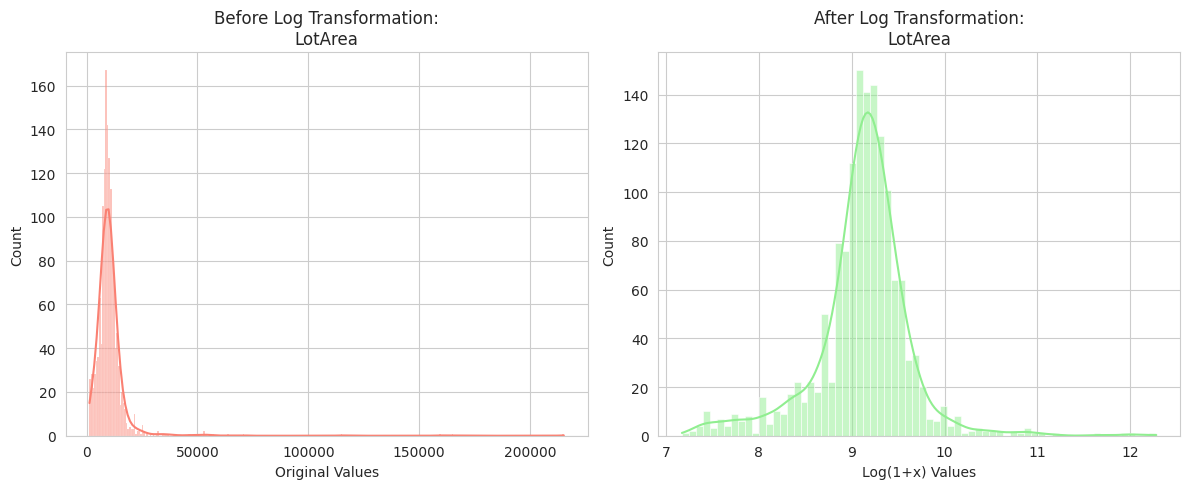

✅ Log transformation applied to all skewed features successfully!


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# 1. Define the list of skewed features to transform
skewed_features_list = high_skew.index.tolist()

# 2. Select the first feature as a visual example (usually the most skewed)
example_feature = skewed_features_list[0]

# 3. Setup the plot configuration
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- PLOT BEFORE ---
sns.histplot(df[example_feature], kde=True, ax=axes[0], color='salmon')
axes[0].set_title(f'Before Log Transformation:\n{example_feature}')
axes[0].set_xlabel('Original Values')

# 4. Apply Log1p transformation to ALL skewed features
for feature in skewed_features_list:
    df[feature] = np.log1p(df[feature])

# --- PLOT AFTER ---
sns.histplot(df[example_feature], kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title(f'After Log Transformation:\n{example_feature}')
axes[1].set_xlabel('Log(1+x) Values')

plt.tight_layout()
plt.show()

print("✅ Log transformation applied to all skewed features successfully!")

---
## 3. Feature Scaling

In this final section of the notebook, we will apply feature scaling. Machine learning models, especially those based on distance calculations or gradient descent, perform much better when all numerical features are on a similar scale. 

We will use the `StandardScaler` from scikit-learn to standardize our numerical features. We strictly exclude our target variable (`SalePrice`) from this scaling process, as we want our model to predict the actual dollar amount, not a scaled value.

In [7]:
from sklearn.preprocessing import StandardScaler

# 1. Identify numerical columns, strictly excluding the target variable 'SalePrice'
features_to_scale = df.select_dtypes(include=['int64', 'float64']).columns
if 'SalePrice' in features_to_scale:
    features_to_scale = features_to_scale.drop('SalePrice')

# 2. Initialize the standard scaler
scaler = StandardScaler()

# 3. Apply the scaler to the selected features
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

# 4. Verify the transformation
print("✅ Feature scaling applied successfully to all numerical features (except SalePrice)!")
df.head()

✅ Feature scaling applied successfully to all numerical features (except SalePrice)!


,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtExposure,BsmtFinSF1,BsmtFinType1,BsmtUnfSF,GarageArea,GarageFinish,GrLivArea,...,LotFrontage,MasVnrArea,OpenPorchSF,OverallCond,OverallQual,TotalBsmtSF,SalePrice,HouseAge,RemodelAge,GarageAge
0,-0.803645,1.241933,0.153895,-0.666314,0.779431,1.153467,-0.340511,0.351000,0.233235,0.529194,...,-0.078896,1.203619,0.845209,-0.517200,0.651479,0.002513,12.247699,-1.050994,-0.878668,-1.017598
1,0.418479,-0.824920,0.153895,2.028309,0.888257,0.666060,0.002218,-0.060731,0.233235,-0.381965,...,0.572719,-0.806841,-1.072916,2.179628,-0.071836,0.341114,12.109016,-0.156734,0.429577,0.107927
2,-0.576677,1.246200,0.153895,0.526075,0.654803,1.153467,0.230372,0.631726,0.233235,0.659631,...,0.062541,1.131524,0.675137,-0.517200,0.651479,0.065397,12.317171,-0.984752,-0.830215,-0.934226
3,-0.439421,-0.824920,0.153895,-0.666314,0.384539,0.666060,0.348034,0.790804,-0.993000,0.541448,...,-0.329561,-0.806841,0.592558,-0.517200,0.651479,-0.105819,11.849405,1.863632,0.720298,-0.809167
4,0.112127,-0.824920,1.416182,1.372089,0.754400,1.153467,0.295711,1.698485,0.233235,1.282295,...,0.726089,1.423411,0.991848,-0.517200,1.374795,0.256237,12.429220,-0.951632,-0.733308,-0.892540


---
## 4. Saving the Engineered Dataset

With all the necessary data cleaning and feature engineering steps completed, our dataset is now fully numerical, scaled, and ready for machine learning algorithms. 

In this final step, we will save this prepared DataFrame into a new CSV file. This ensures our predictive model in the next stage has a clean, reliable, and standardized data source to learn from, without needing to re-run all the previous transformations.

In [9]:
import os

# We add '../' to move up one directory level from jupyter_notebooks to the project root
output_path = '../outputs/datasets/collection/house_prices_records_engineered.csv'

# Create the directory if it doesn't exist for safety
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# Save the dataframe to a CSV file, ignoring the index column
df.to_csv(output_path, index=False)

print(f"✅ Success! Engineered dataset saved to: {output_path}")

✅ Success! Engineered dataset saved to: ../outputs/datasets/collection/house_prices_records_engineered.csv
